In [5]:
"""
King County Housing Data - Exploratory Data Analysis (EDA)
-----------------------------------------------------------

This notebook performs an exploratory data analysis (EDA) on the King County
housing prices dataset. It covers:

- Data loading and initial inspection
- Missing value checks
- Outlier filtering
- Visual exploration of feature relationships
- Feature engineering (dates, renovations)
- Correlation and trend analysis

All visualizations are built using Seaborn and Matplotlib.
"""


'\nKing County Housing Data - Exploratory Data Analysis (EDA)\n-----------------------------------------------------------\n\nThis notebook performs an exploratory data analysis (EDA) on the King County\nhousing prices dataset. It covers:\n\n- Data loading and initial inspection\n- Missing value checks\n- Outlier filtering\n- Visual exploration of feature relationships\n- Feature engineering (dates, renovations)\n- Correlation and trend analysis\n\nAll visualizations are built using Seaborn and Matplotlib.\n'

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


In [7]:

DATA_PATH = '/mnt/mls/data/udemy/kc_house_data.csv'

# Read the data
df = pd.read_csv(DATA_PATH)


In [8]:

print(df.head())
print(df.isna().sum())


           id        date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  10/13/2014  221900.0         3       1.00         1180   
1  6414100192   12/9/2014  538000.0         3       2.25         2570   
2  5631500400   2/25/2015  180000.0         2       1.00          770   
3  2487200875   12/9/2014  604000.0         4       3.00         1960   
4  1954400510   2/18/2015  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     long  sqft_living15  \
0      19

<Figure size 2400x800 with 0 Axes>

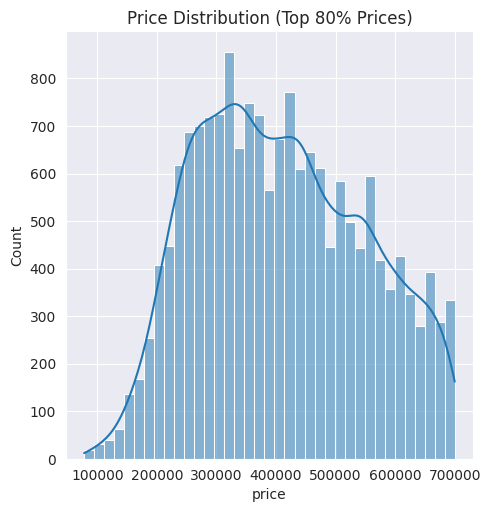

In [9]:

fig = plt.figure(figsize=(24, 8))
filtered_df = df[df['price'] <= df['price'].quantile(0.8)]
sns.displot(filtered_df['price'], kde=True)
plt.title('Price Distribution (Top 80% Prices)')
plt.show()


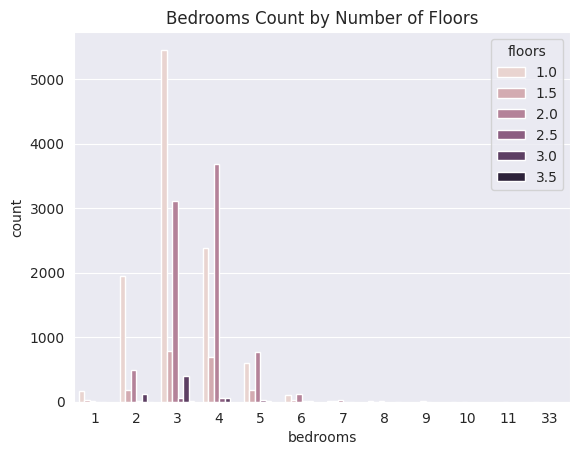

In [10]:

sns.countplot(data=df, x='bedrooms', hue='floors')
plt.title('Bedrooms Count by Number of Floors')
plt.show()


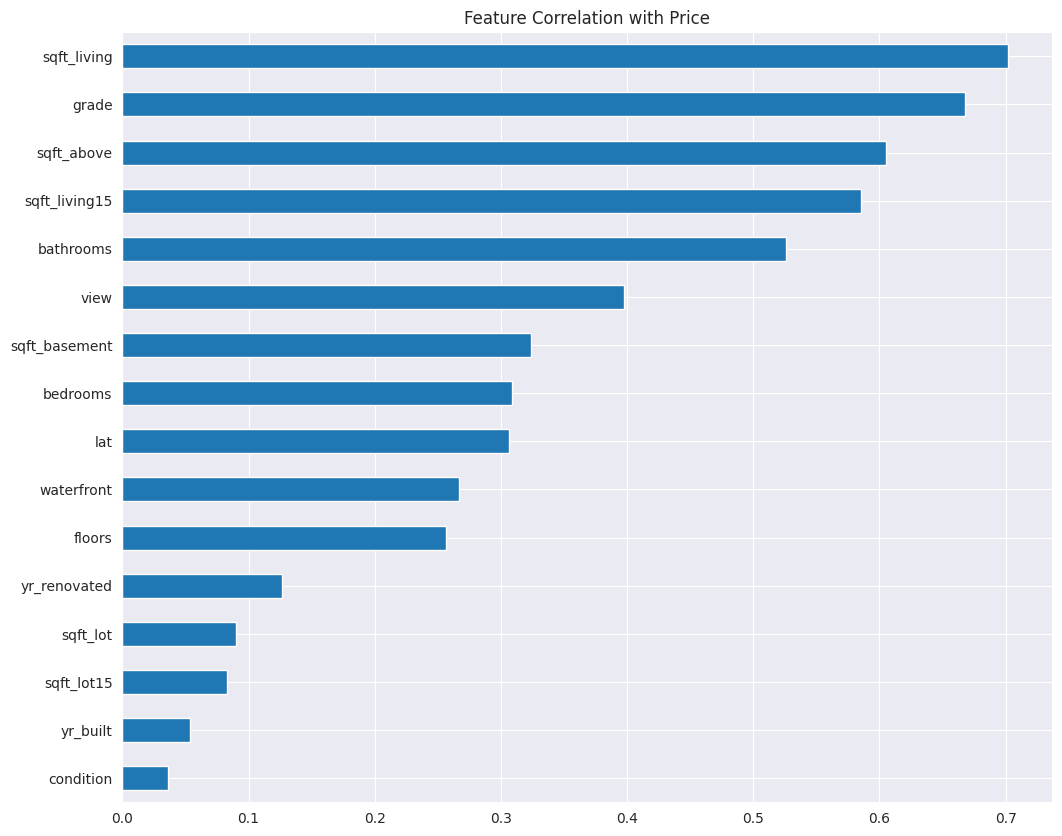

In [11]:

price_corr = df.drop(['date', 'zipcode', 'id', 'long'], axis=1).corr()['price'].sort_values(ascending=True)
price_corr[:-1].plot(kind='barh', figsize=(12, 10))
plt.title('Feature Correlation with Price')
plt.show()


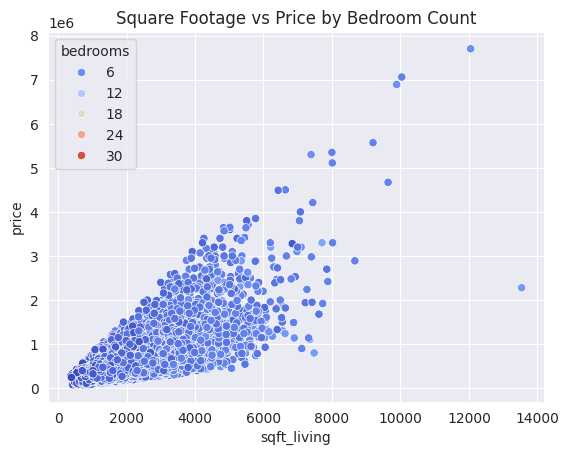

In [12]:

sns.scatterplot(x='sqft_living', y='price', data=df, hue='bedrooms', palette='coolwarm')
plt.title('Square Footage vs Price by Bedroom Count')
plt.show()


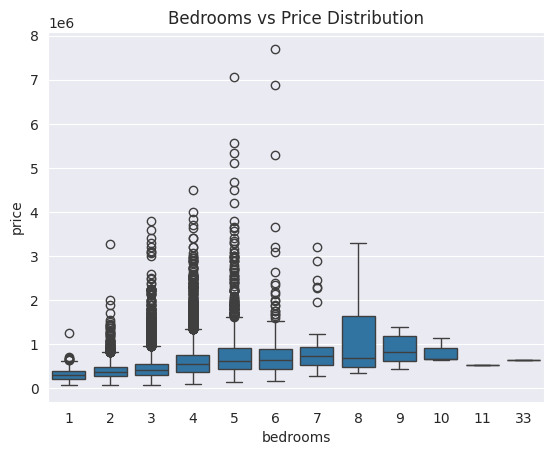

In [13]:

sns.boxplot(x='bedrooms', y='price', data=df)
plt.title('Bedrooms vs Price Distribution')
plt.show()


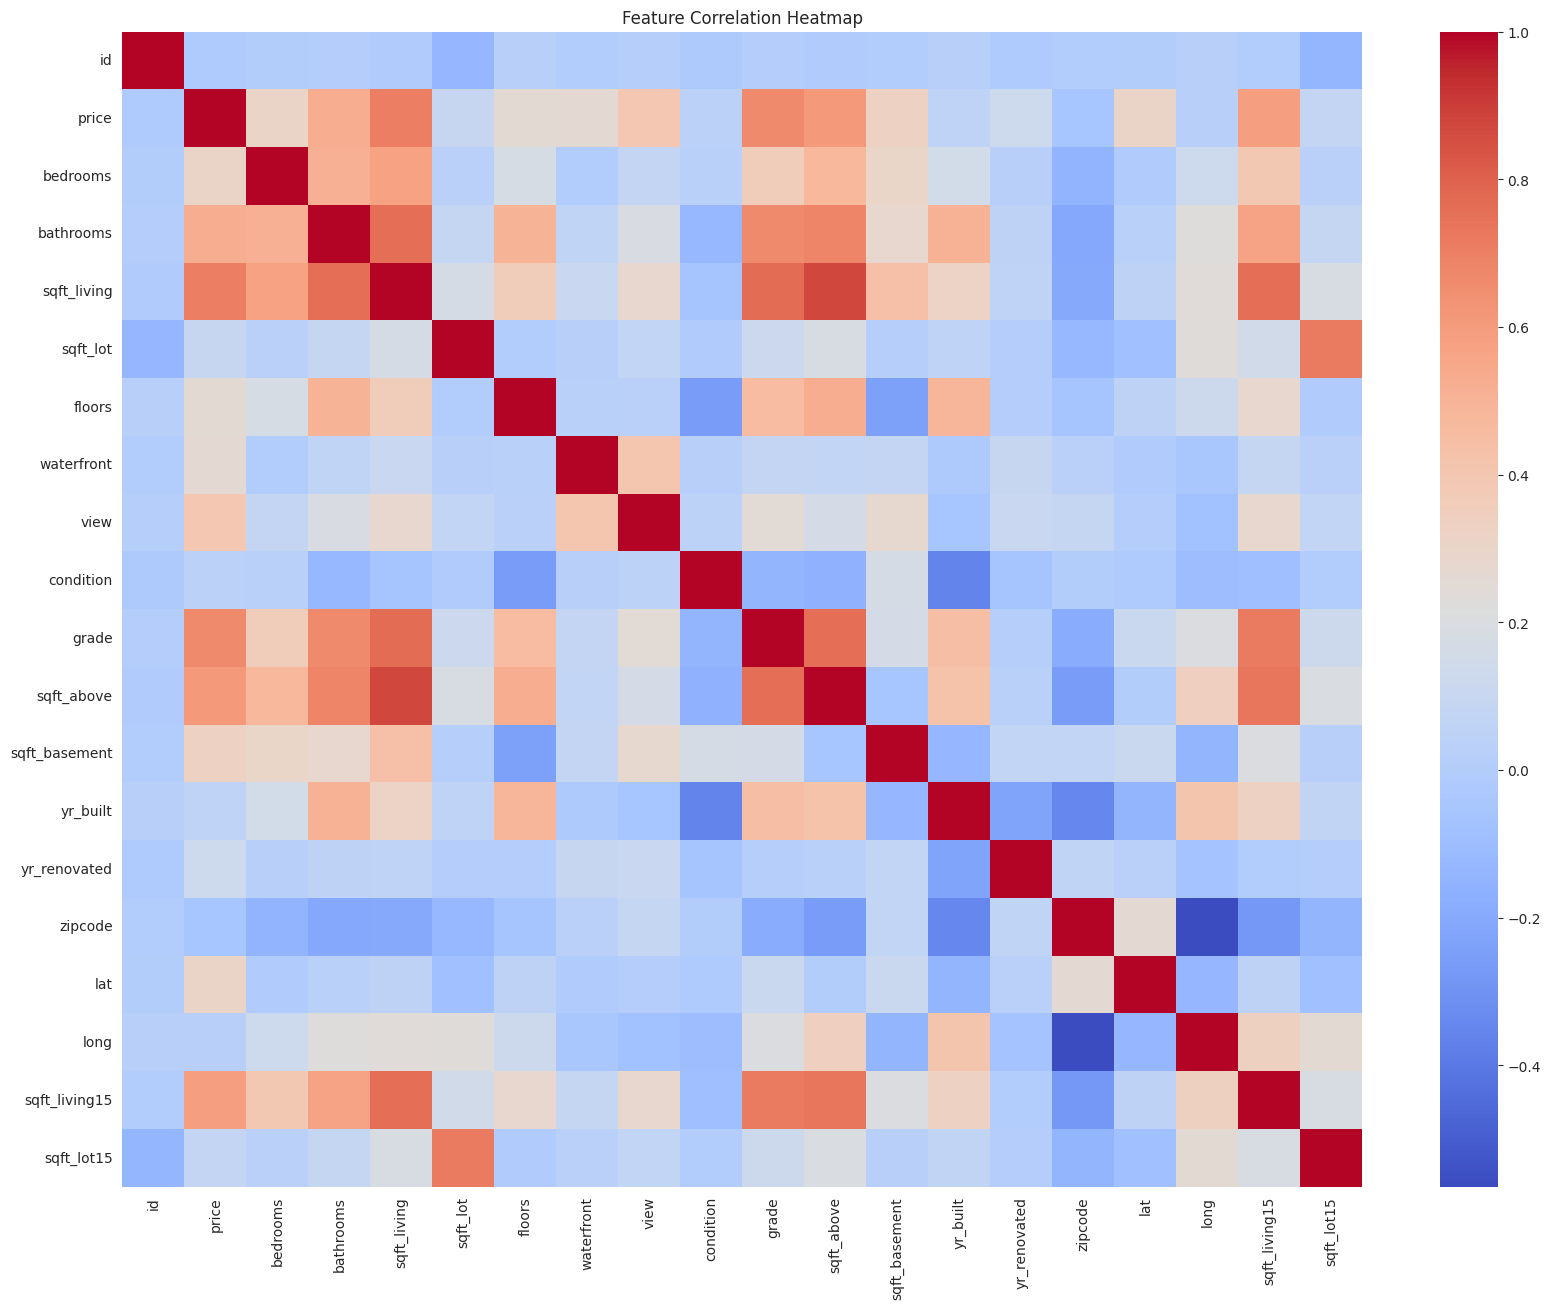

In [14]:

fig = plt.figure(figsize=(20, 15))
sns.heatmap(df.drop('date', axis=1).corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()


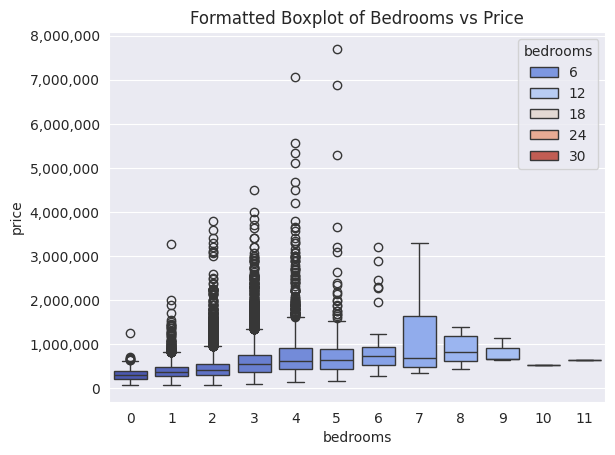

In [15]:

sns.boxplot(x='bedrooms', y='price', data=df, hue='bedrooms', palette='coolwarm')
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Formatted Boxplot of Bedrooms vs Price')
plt.show()


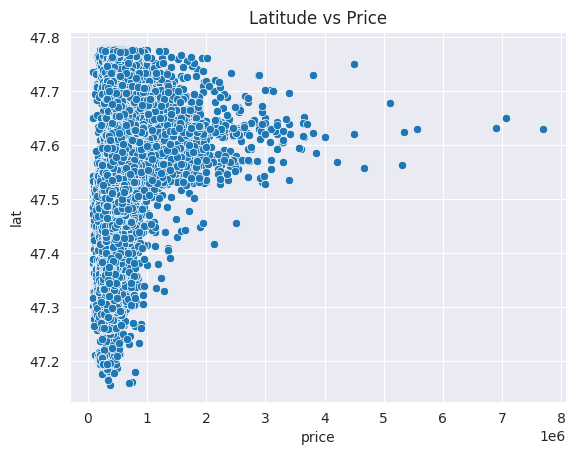

In [16]:

sns.scatterplot(data=df, x='price', y='lat')
plt.title('Latitude vs Price')
plt.show()


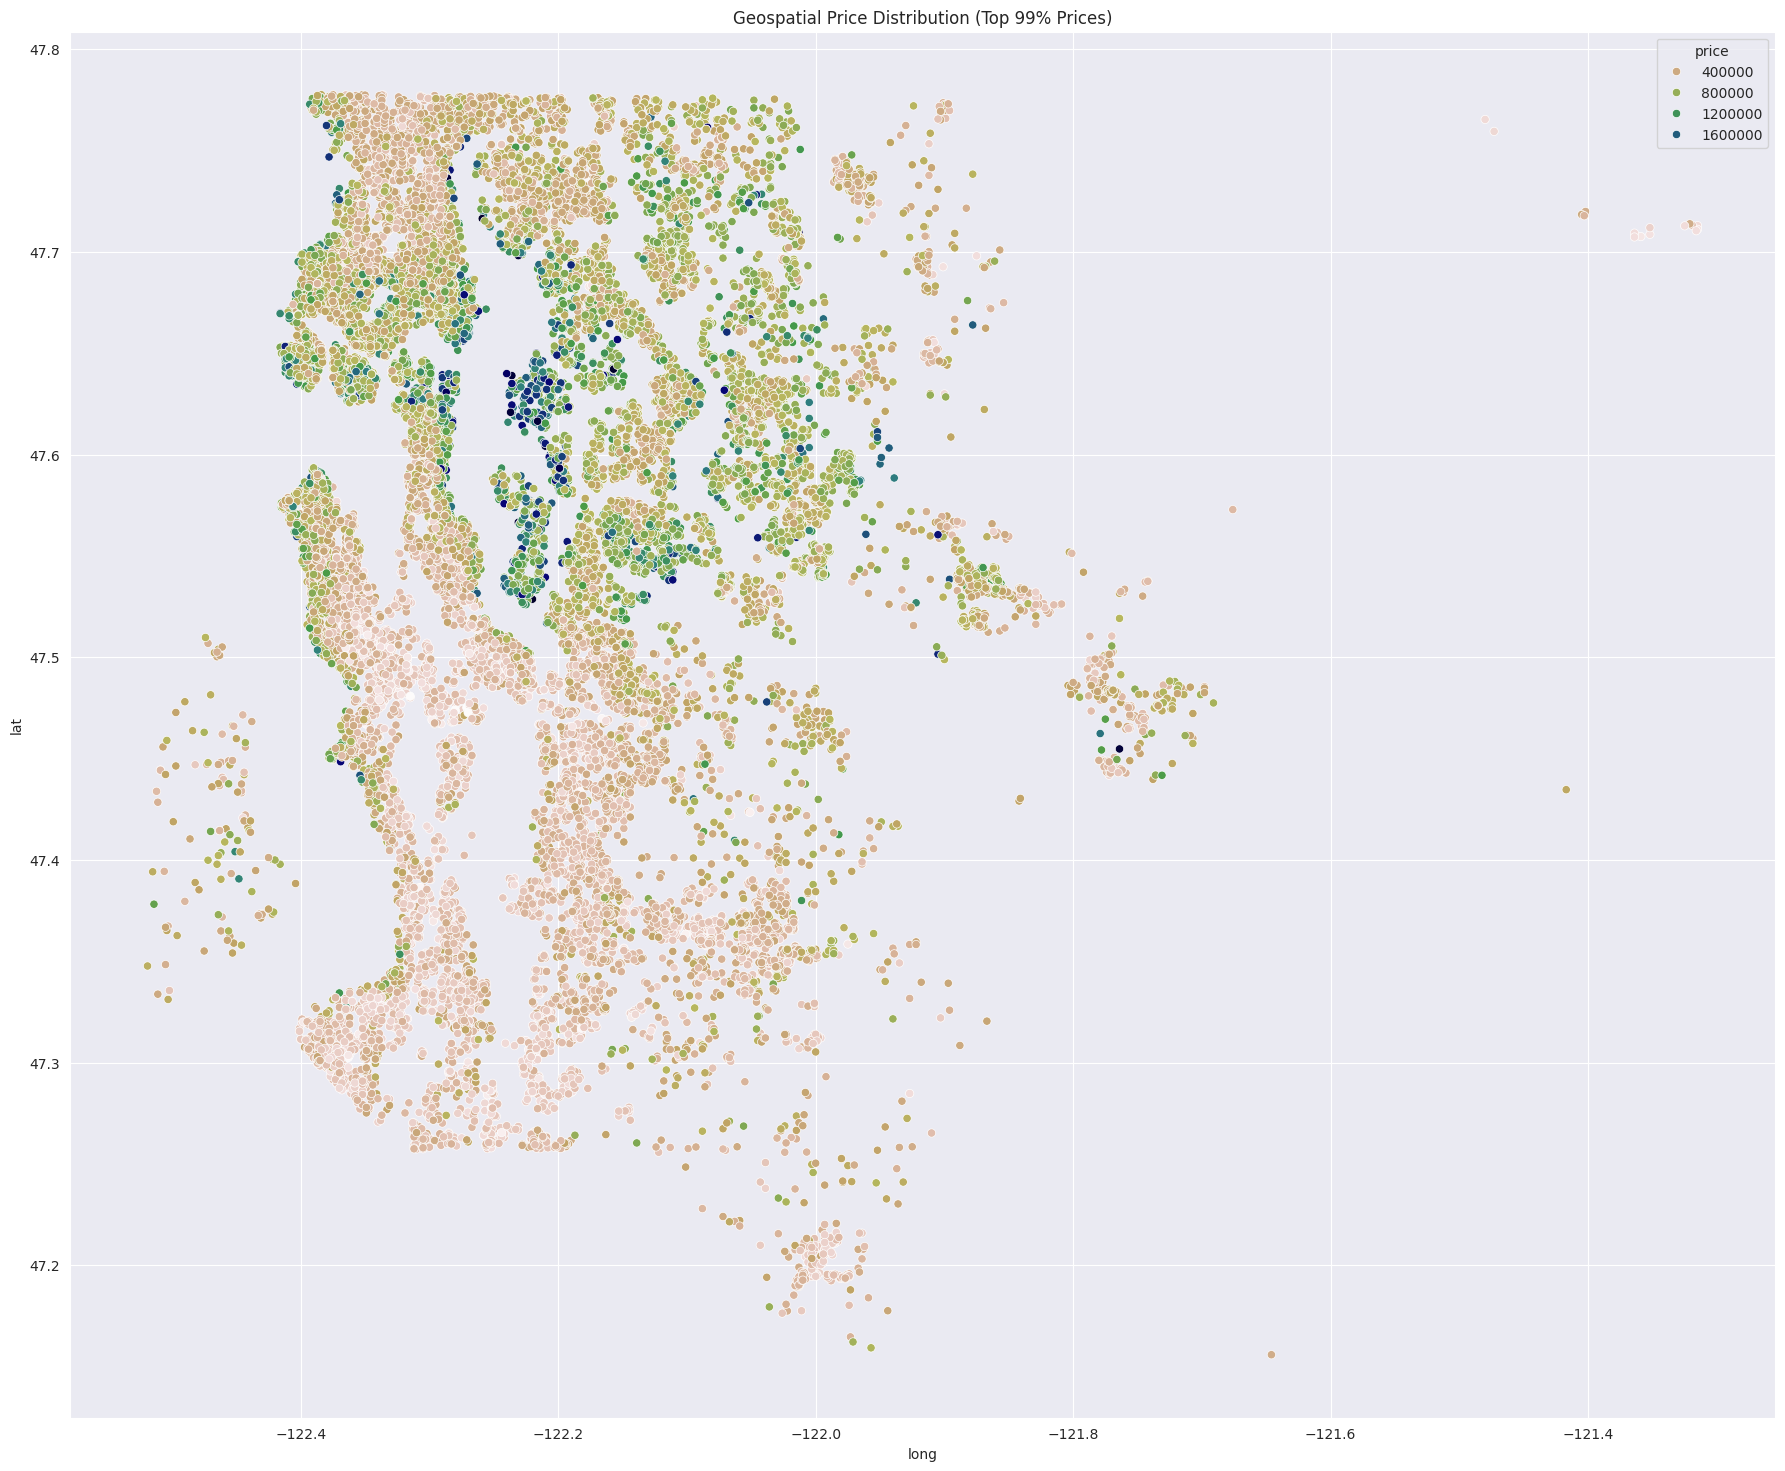

In [17]:

fig = plt.figure(figsize=(22, 18))
sns.scatterplot(df[df['price'] <= df['price'].quantile(0.99)], x='long', y='lat', hue='price', palette='gist_earth_r')
plt.title('Geospatial Price Distribution (Top 99% Prices)')
plt.show()


In [18]:

df['date'] = pd.to_datetime(df['date'])
df.drop('id', axis=1, inplace=True)

# Extract year and month sold

df['year_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month


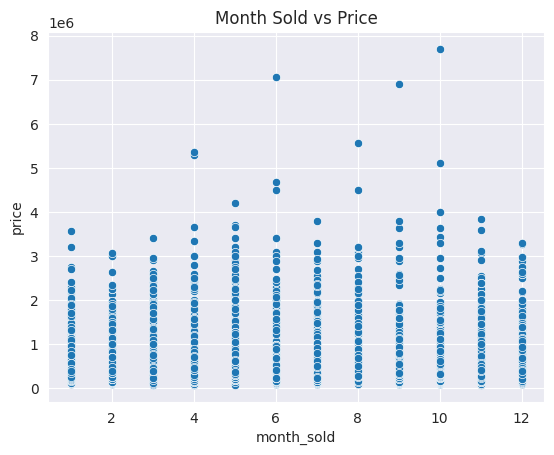

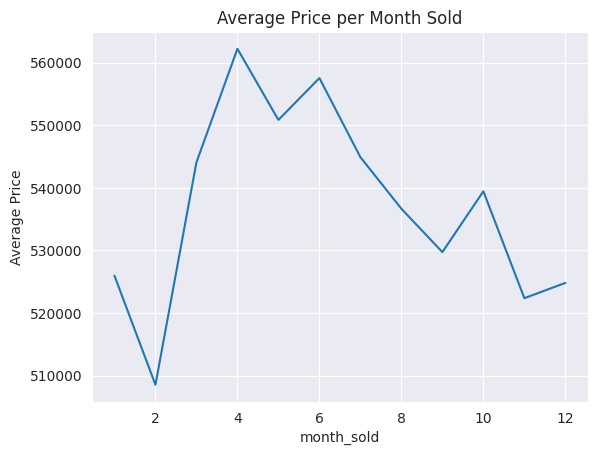

In [19]:

sns.scatterplot(x='month_sold', y='price', data=df)
plt.title('Month Sold vs Price')
plt.show()

# Average price per month

df.groupby('month_sold')['price'].mean().plot()
plt.title('Average Price per Month Sold')
plt.ylabel('Average Price')
plt.show()


In [20]:

# If a house wasn't renovated, use year built

df['year_renovated_rev'] = df.apply(lambda row: row['yr_renovated'] if row['yr_renovated'] > 0 else row['yr_built'], axis=1)
df['is_renovated'] = df['yr_renovated'] > 0


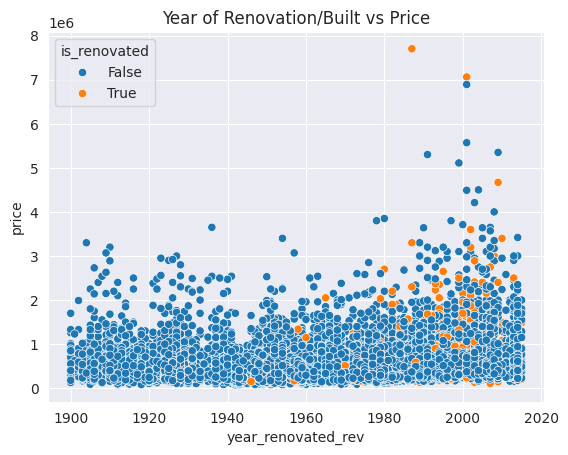

In [21]:

sns.scatterplot(x='year_renovated_rev', y='price', data=df, hue='is_renovated')
plt.title('Year of Renovation/Built vs Price')
plt.show()
